In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/uber.csv")
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [4]:
df[df["dropoff_latitude"].isnull()]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:51:57.0000001,24.1,2013-07-02 03:51:57 UTC,-73.950581,40.779692,NaN,NaN,0


In [5]:
df = df.dropna()

In [6]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [7]:
df[(df["pickup_latitude"] == 0) | (df["dropoff_latitude"] == 0)]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
7,44195482,2012-12-11 13:52:00.00000029,2.5,2012-12-11 13:52:00 UTC,0.0,0.0,0.0,0.0,1
11,6379048,2011-05-23 22:15:00.00000086,8.5,2011-05-23 22:15:00 UTC,0.0,0.0,0.0,0.0,1
65,21993993,2014-05-05 19:27:00.00000034,6.0,2014-05-05 19:27:00 UTC,0.0,0.0,0.0,0.0,1
92,1454546,2011-12-02 14:07:00.000000207,6.1,2011-12-02 14:07:00 UTC,0.0,0.0,0.0,0.0,1
120,17358122,2010-08-20 19:39:48.0000003,6.5,2010-08-20 19:39:48 UTC,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...
199718,49162936,2011-08-19 07:16:00.00000037,4.9,2011-08-19 07:16:00 UTC,0.0,0.0,0.0,0.0,1
199724,46007628,2013-10-11 11:25:41.0000004,7.5,2013-10-11 11:25:41 UTC,0.0,0.0,0.0,0.0,1
199880,35013970,2014-02-22 06:45:46.0000002,6.5,2014-02-22 06:45:46 UTC,0.0,0.0,0.0,0.0,1
199883,44115598,2012-09-10 17:39:00.00000090,12.5,2012-09-10 17:39:00 UTC,0.0,0.0,0.0,0.0,2


In [8]:
df = df[df["pickup_latitude"] != 0]
df = df[df["dropoff_latitude"] != 0]

In [9]:
df[(df["pickup_latitude"] == 0) | (df["dropoff_latitude"] == 0)]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count


In [10]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [11]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1.960460e+05,196046.000000,196046.000000,196046.000000,196046.000000,196046.000000,196046.000000
mean,2.771222e+07,11.343103,-73.927418,40.705594,-73.914095,40.688385,1.685217
std,1.600922e+07,9.799573,5.467037,5.426637,8.530961,3.995199,1.388126
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.383123e+07,6.000000,-73.992268,40.736394,-73.991592,40.735265,1.000000
50%,2.774878e+07,8.500000,-73.982101,40.753287,-73.980521,40.753726,1.000000
75%,4.154483e+07,12.500000,-73.968312,40.767542,-73.965314,40.768326,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196046 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         196046 non-null  int64  
 1   key                196046 non-null  object 
 2   fare_amount        196046 non-null  float64
 3   pickup_datetime    196046 non-null  object 
 4   pickup_longitude   196046 non-null  float64
 5   pickup_latitude    196046 non-null  float64
 6   dropoff_longitude  196046 non-null  float64
 7   dropoff_latitude   196046 non-null  float64
 8   passenger_count    196046 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 15.0+ MB


Observation:
There was 1 missing value in dropoff_latitude and dropoff_longitude.

Action:
Since distance calculation requires both coordinates and the number
of missing rows was extremely small, the row was removed.


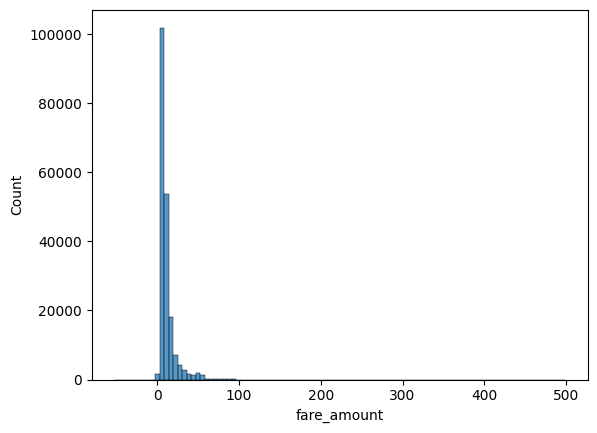

In [13]:
sns.histplot(df["fare_amount"], bins=100)
plt.show()

<Axes: xlabel='passenger_count', ylabel='count'>

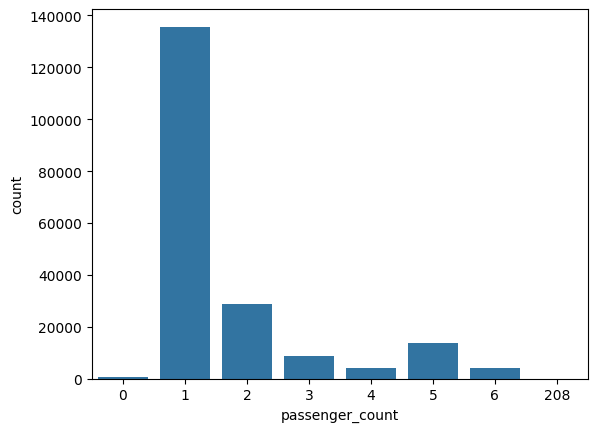

In [14]:
sns.countplot(x="passenger_count", data=df)